In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive connected!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected!


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/dataset.csv')
print("Dataset loaded!")
print("Shape:", df.shape)
print(df.head())

✅ Dataset loaded!
Shape: (4424, 35)
   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                      13                      10                  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

np.random.seed(42)
print("All imports done!")

All imports done!


In [ ]:
# Convert 3-class target → binary
df["dropout"] = (df["Target"] == "Dropout").astype(int)

print("Target distribution:")
print(df["dropout"].value_counts())
print(f"\nDropout rate: {df['dropout'].mean()*100:.1f}%")

Target distribution:
dropout
0    3003
1    1421
Name: count, dtype: int64

Dropout rate: 32.1%


In [ ]:
# Map project features from real dataset columns
df["gpa"] = (df["Curricular units 1st sem (grade)"] +
             df["Curricular units 2nd sem (grade)"]) / 2

df["attendance"] = df["Daytime/evening attendance"]

df["engagement"] = (df["Curricular units 1st sem (enrolled)"] +
                    df["Curricular units 2nd sem (enrolled)"] +
                    df["Curricular units 1st sem (approved)"] +
                    df["Curricular units 2nd sem (approved)"]) / 4

df["income_proxy"] = df["Scholarship holder"] * 2 + (1 - df["Debtor"])

# Risk flags
df["low_gpa_flag"]        = (df["gpa"] < 5).astype(int)
df["low_engagement_flag"] = (df["engagement"] < 3).astype(int)
df["risk_score"]          = df["low_gpa_flag"] + df["low_engagement_flag"]

FEATURES = ["gpa", "attendance", "engagement", "income_proxy",
            "low_gpa_flag", "low_engagement_flag", "risk_score",
            "Unemployment rate", "Age at enrollment", "Gender"]

X = df[FEATURES]
y = df["dropout"]

print("✅ Features ready!")
print(X.head())

✅ Features ready!
         gpa  attendance  engagement  income_proxy  low_gpa_flag  \
0   0.000000           1        0.00             1             1   
1  13.833333           1        6.00             1             0   
2   0.000000           1        3.00             1             1   
3  12.914286           1        5.75             1             0   
4  12.666667           0        5.75             1             0   

   low_engagement_flag  risk_score  Unemployment rate  Age at enrollment  \
0                    1           2               10.8                 20   
1                    0           0               13.9                 19   
2                    0           1               10.8                 19   
3                    0           0                9.4                 20   
4                    0           0               13.9                 45   

   Gender  
0       1  
1       1  
2       1  
3       0  
4       0  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Split done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Split done!
Training samples : 3539
Testing samples  : 885


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost"            : XGBClassifier(n_estimators=200, use_label_encoder=False,
                                          eval_metric="logloss", random_state=42),
}

results       = {}
trained_models = {}

for name, model in models.items():
    X_tr = X_train_sc if name == "Logistic Regression" else X_train
    X_te = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred),
        "ROC-AUC"  : roc_auc_score(y_test, y_proba),
    }
    trained_models[name] = {"model": model, "y_pred": y_pred, "y_proba": y_proba}
    print(f"✅ {name} trained!")

✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!


In [ ]:
results_df = pd.DataFrame(results).T.round(4)
print("=" * 55)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(results_df.to_string())

best = max(results, key=lambda k: results[k]["ROC-AUC"])
print(f"\n Best model: {best}")

MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8362     0.8325  0.6127    0.7059   0.8763
Random Forest          0.8203     0.7753  0.6197    0.6888   0.8765
XGBoost                0.8124     0.7418  0.6373    0.6856   0.8486

 Best model: Random Forest


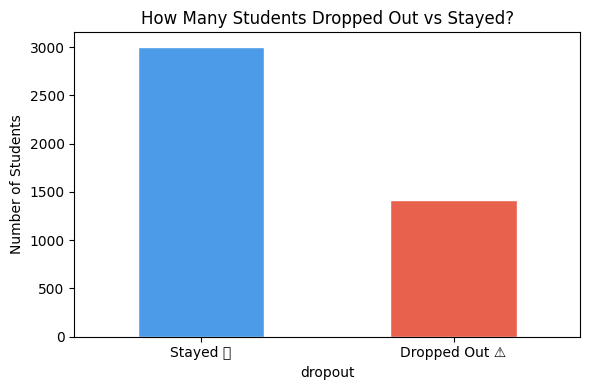

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
df["dropout"].value_counts().plot(kind="bar",
    color=["#4C9BE8","#E8614C"], edgecolor="white")
plt.title("How Many Students Dropped Out vs Stayed?")
plt.xticks([0,1], ["Stayed ✅","Dropped Out ⚠️"], rotation=0)
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

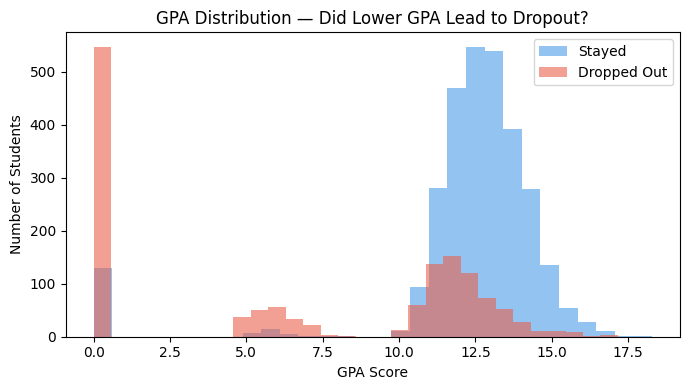

In [ ]:
plt.figure(figsize=(7,4))
for label, color, name in [(0,"#4C9BE8","Stayed"),(1,"#E8614C","Dropped Out")]:
    subset = df[df["dropout"]==label]["gpa"]
    plt.hist(subset, bins=30, alpha=0.6, color=color, label=name)
plt.title("GPA Distribution — Did Lower GPA Lead to Dropout?")
plt.xlabel("GPA Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.show()

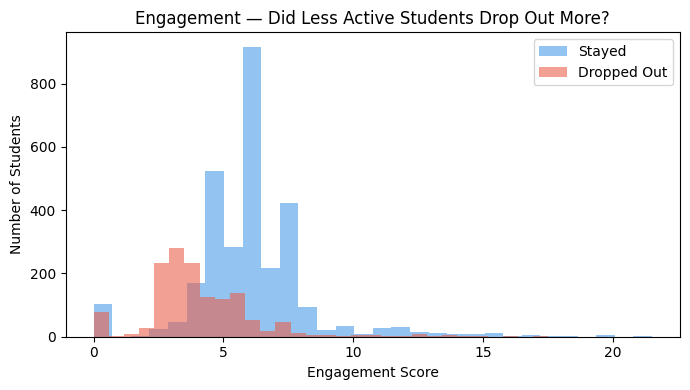

In [ ]:
plt.figure(figsize=(7,4))
for label, color, name in [(0,"#4C9BE8","Stayed"),(1,"#E8614C","Dropped Out")]:
    subset = df[df["dropout"]==label]["engagement"]
    plt.hist(subset, bins=30, alpha=0.6, color=color, label=name)
plt.title("Engagement — Did Less Active Students Drop Out More?")
plt.xlabel("Engagement Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.show()

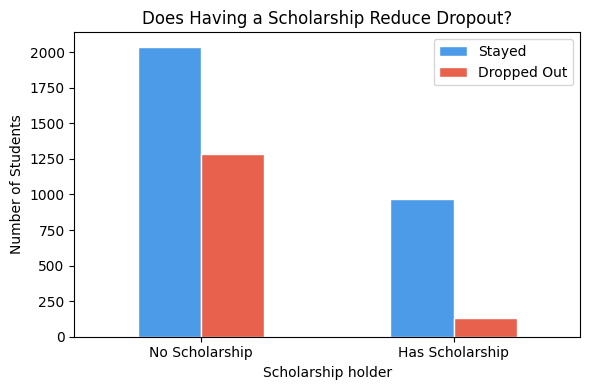

In [ ]:
scholarship_dropout = df.groupby(["Scholarship holder","dropout"]).size().unstack()
scholarship_dropout.plot(kind="bar", color=["#4C9BE8","#E8614C"],
                         edgecolor="white", figsize=(6,4))
plt.title("Does Having a Scholarship Reduce Dropout?")
plt.xticks([0,1], ["No Scholarship","Has Scholarship"], rotation=0)
plt.ylabel("Number of Students")
plt.legend(["Stayed","Dropped Out"])
plt.tight_layout()
plt.show()

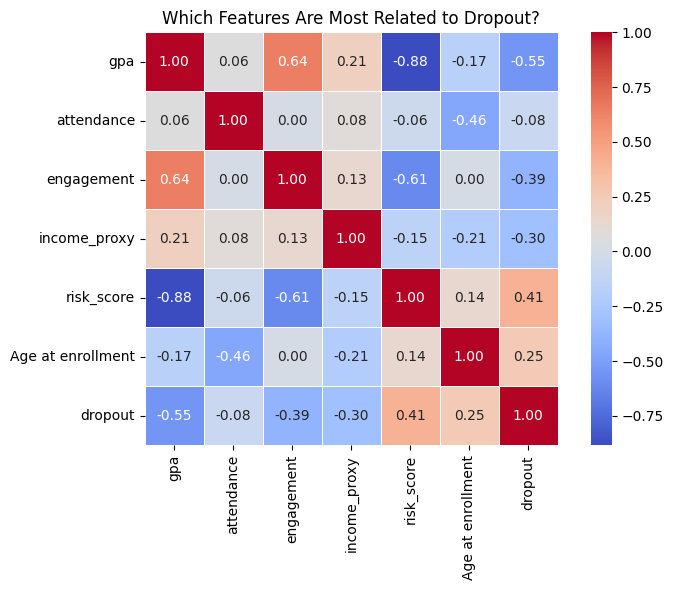

In [ ]:
plt.figure(figsize=(8,6))
corr_cols = ["gpa","attendance","engagement","income_proxy",
             "risk_score","Age at enrollment","dropout"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Which Features Are Most Related to Dropout?")
plt.tight_layout()
plt.show()

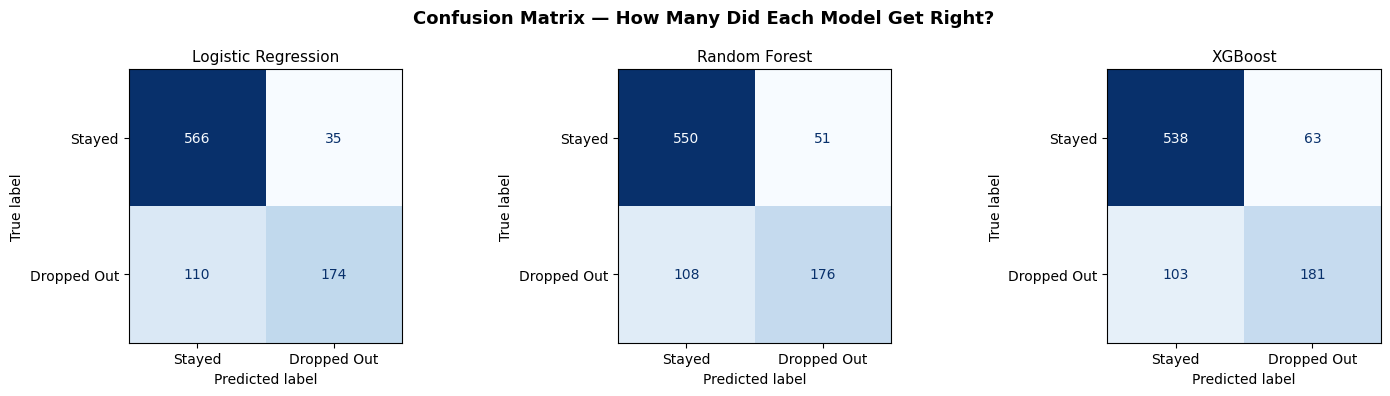

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle("Confusion Matrix — How Many Did Each Model Get Right?",
             fontsize=13, fontweight="bold")

for ax, (name, info) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, info["y_pred"])
    disp = ConfusionMatrixDisplay(cm,
               display_labels=["Stayed","Dropped Out"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

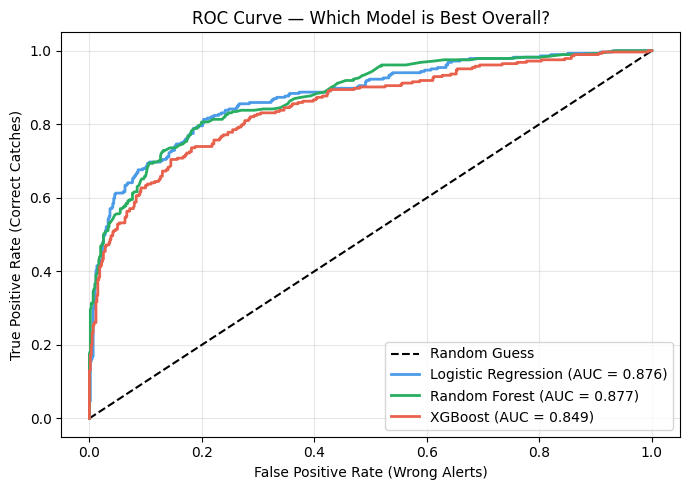

In [ ]:
plt.figure(figsize=(7,5))
plt.plot([0,1],[0,1],"k--", label="Random Guess")

colors = {"Logistic Regression":"#4C9BE8",
          "Random Forest":"#27AE60",
          "XGBoost":"#E8614C"}

for name, info in trained_models.items():
    fpr, tpr, _ = roc_curve(y_test, info["y_proba"])
    auc = results[name]["ROC-AUC"]
    plt.plot(fpr, tpr, lw=2, color=colors[name],
             label=f"{name} (AUC = {auc:.3f})")

plt.title("ROC Curve — Which Model is Best Overall?")
plt.xlabel("False Positive Rate (Wrong Alerts)")
plt.ylabel("True Positive Rate (Correct Catches)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

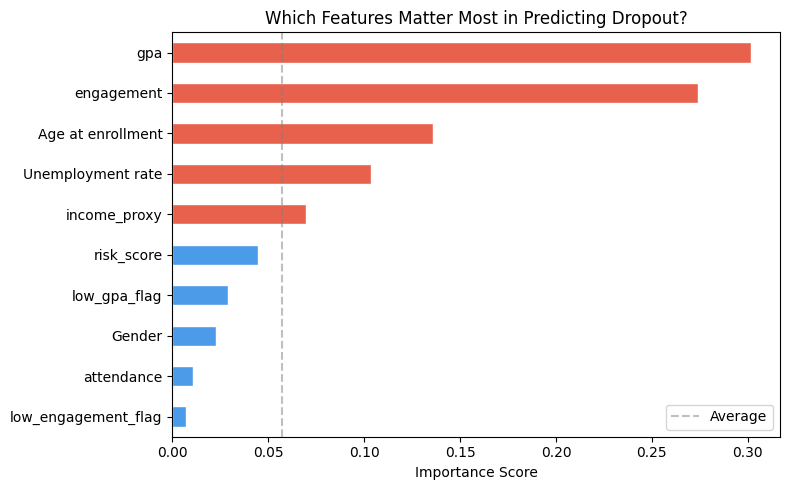

In [ ]:
import pandas as pd

rf_model    = trained_models["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_,
                        index=FEATURES).sort_values()

colors_fi = ["#E8614C" if v > importances.median()
             else "#4C9BE8" for v in importances]

importances.plot(kind="barh", color=colors_fi,
                 figsize=(8,5), edgecolor="white")
plt.title("Which Features Matter Most in Predicting Dropout?")
plt.xlabel("Importance Score")
plt.axvline(importances.median(), color="gray",
            linestyle="--", alpha=0.5, label="Average")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save all 3 models
joblib.dump(trained_models["Random Forest"]["model"],
            "random_forest_model.pkl")
joblib.dump(trained_models["Logistic Regression"]["model"],
            "logistic_regression_model.pkl")
joblib.dump(trained_models["XGBoost"]["model"],
            "xgboost_model.pkl")

# Save the best model separately
joblib.dump(trained_models["Random Forest"]["model"],
            "best_model.pkl")

# Save the scaler (needed for Logistic Regression later)
joblib.dump(scaler, "scaler.pkl")

print("✅ All models saved!")

✅ All models saved!


In [ ]:
from google.colab import files

files.download("best_model.pkl")
files.download("random_forest_model.pkl")
files.download("logistic_regression_model.pkl")
files.download("xgboost_model.pkl")
files.download("scaler.pkl")

print("✅ All files downloaded to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded to your computer!


In [ ]:

import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

# Setup LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data  = np.array(X_train),
    feature_names  = FEATURES,
    class_names    = ["Stayed", "Dropped Out"],
    mode           = "classification"
)
print("✅ LIME explainer ready!")

✅ LIME explainer ready!


STUDENT 1 — Predicted: DROPOUT ⚠️
Dropout Probability: 62.0%

Top Reasons (LIME):
  gpa <= 10.92: 0.3624 → pushes TOWARD dropout ❌
  engagement <= 4.00: 0.3097 → pushes TOWARD dropout ❌
  income_proxy <= 1.00: 0.0856 → pushes TOWARD dropout ❌
  risk_score <= 0.00: -0.0841 → pushes AWAY from dropout ✅
  low_gpa_flag <= 0.00: -0.0521 → pushes AWAY from dropout ✅
  Age at enrollment <= 19.00: -0.0335 → pushes AWAY from dropout ✅
  Unemployment rate <= 9.40: -0.0205 → pushes AWAY from dropout ✅
  0.00 < Gender <= 1.00: 0.0155 → pushes TOWARD dropout ❌
  low_engagement_flag <= 0.00: -0.0154 → pushes AWAY from dropout ✅
  attendance <= 1.00: 0.0000 → pushes AWAY from dropout ✅


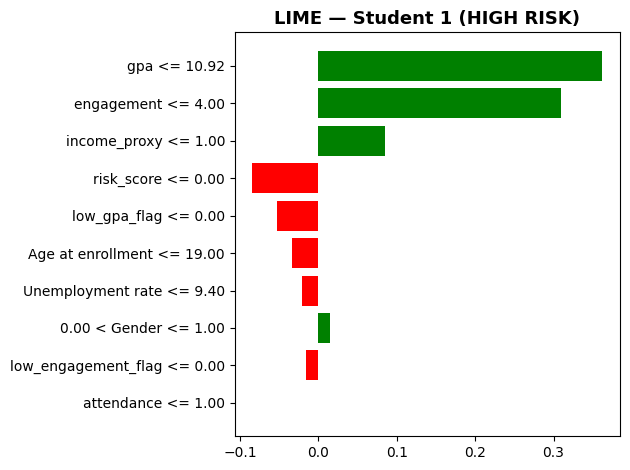

In [ ]:
# Find a student the model predicted as dropout
dropout_indices = np.where(
    trained_models["Random Forest"]["y_pred"] == 1)[0]
student_1_idx = dropout_indices[0]
student_1     = np.array(X_test)[student_1_idx]

# Generate explanation
exp1 = explainer.explain_instance(
    data_row       = student_1,
    predict_fn     = trained_models["Random Forest"]["model"].predict_proba,
    num_features   = len(FEATURES)
)

print("=" * 50)
print("STUDENT 1 — Predicted: DROPOUT ⚠️")
print("=" * 50)
print(f"Dropout Probability: "
      f"{trained_models['Random Forest']['y_proba'][student_1_idx]*100:.1f}%")
print("\nTop Reasons (LIME):")
for feat, weight in exp1.as_list():
    direction = "pushes TOWARD dropout ❌" if weight > 0 \
                else "pushes AWAY from dropout ✅"
    print(f"  {feat}: {weight:.4f} → {direction}")

# Plot
fig = exp1.as_pyplot_figure()
plt.title("LIME — Student 1 (HIGH RISK)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

STUDENT 2 — Predicted: WILL STAY ✅
Dropout Probability: 2.0%

Top Reasons (LIME):
  5.50 < engagement <= 6.00: -0.1504 → pushes AWAY from dropout ✅
  12.25 < gpa <= 13.27: -0.1324 → pushes AWAY from dropout ✅
  income_proxy > 1.00: -0.0975 → pushes AWAY from dropout ✅
  risk_score <= 0.00: -0.0775 → pushes AWAY from dropout ✅
  low_gpa_flag <= 0.00: -0.0626 → pushes AWAY from dropout ✅
  Age at enrollment <= 19.00: -0.0352 → pushes AWAY from dropout ✅
  Unemployment rate <= 9.40: -0.0295 → pushes AWAY from dropout ✅
  Gender <= 0.00: -0.0179 → pushes AWAY from dropout ✅
  low_engagement_flag <= 0.00: -0.0161 → pushes AWAY from dropout ✅
  attendance <= 1.00: 0.0000 → pushes AWAY from dropout ✅


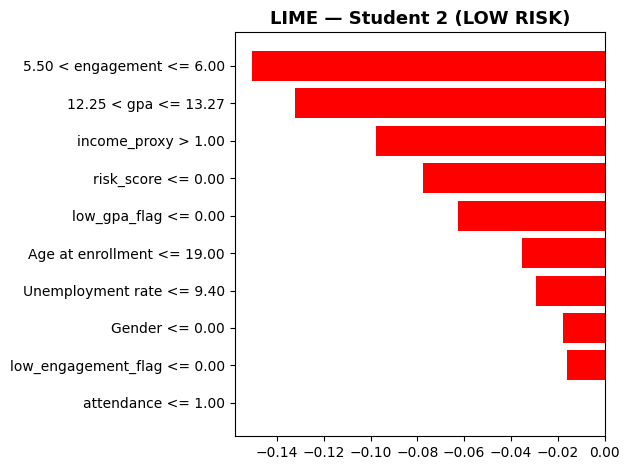

In [ ]:
# Find a student predicted as NOT dropout
stayed_indices = np.where(
    trained_models["Random Forest"]["y_pred"] == 0)[0]
student_2_idx = stayed_indices[0]
student_2     = np.array(X_test)[student_2_idx]

exp2 = explainer.explain_instance(
    data_row       = student_2,
    predict_fn     = trained_models["Random Forest"]["model"].predict_proba,
    num_features   = len(FEATURES)
)

print("=" * 50)
print("STUDENT 2 — Predicted: WILL STAY ✅")
print("=" * 50)
print(f"Dropout Probability: "
      f"{trained_models['Random Forest']['y_proba'][student_2_idx]*100:.1f}%")
print("\nTop Reasons (LIME):")
for feat, weight in exp2.as_list():
    direction = "pushes TOWARD dropout ❌" if weight > 0 \
                else "pushes AWAY from dropout ✅"
    print(f"  {feat}: {weight:.4f} → {direction}")

fig = exp2.as_pyplot_figure()
plt.title("LIME — Student 2 (LOW RISK)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
!pip install shap
import shap

rf_model = trained_models["Random Forest"]["model"]

# Create SHAP explainer
shap_explainer = shap.TreeExplainer(rf_model)
shap_values    = shap_explainer.shap_values(X_test)

print("✅ SHAP values calculated!")
print(f"Shape of SHAP values: {np.array(shap_values).shape}")

✅ SHAP values calculated!
Shape of SHAP values: (885, 10, 2)
